<a href="https://colab.research.google.com/github/meganjohnson0522/INFO648/blob/main/Final/Final_Project_INFO_648.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# #Like class

# student_tracts = pd.read_csv('student_tracts_raw.csv')
# forecast_tracts = pd.read_csv('forecast_tracts_2020.csv')
# region_counts = pd.read_csv('region_tract_counts.csv')
# data_dict = pd.read_csv('data_dictionary.csv')

In [ ]:
# Load dataframes from the local environment
student_tracts = pd.read_csv ("/content/student_tracts_raw.csv")
forecast_tracts = pd.read_csv ("/content/forecast_tracts_2020.csv")
region_counts = pd.read_csv ("/content/region_tract_counts.csv")
data_dict = pd.read_csv ("/content/data_dictionary.csv")

#confirm the shapes look about right
print(student_tracts.shape)
print(forecast_tracts.shape)
print(region_counts.shape)
print(data_dict.shape)

(73057, 49)
(73057, 48)
(9, 4)
(17, 2)


In [ ]:
student_tracts.head()

,GISJOIN,STATE,STATEA,COUNTY,COUNTYA,TRACTA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type
0,G0100010020100,Alabama,1,Autauga County,1,20100,1912,693,59,536,...,21,0,1,0,13,9,1775.0,9.809944,194.904273,suburban
1,G0100010020200,Alabama,1,Autauga County,1,20200,2170,743,79,469,...,44,3,0,0,24,4,2055.0,3.340505,649.602380,suburban
2,G0100010020300,Alabama,1,Autauga County,1,20300,3373,1256,70,949,...,38,0,2,0,28,19,3216.0,5.349274,630.552856,suburban
3,G0100010020400,Alabama,1,Autauga County,1,20400,4386,1722,101,1357,...,56,2,0,1,21,5,4246.0,6.382705,687.169468,suburban
4,G0100010020500,Alabama,1,Autauga County,1,20500,10766,4082,226,2459,...,228,19,4,4,78,22,11222.0,11.397725,944.574466,suburban


In [ ]:
forecast_tracts.head()

,GISJOIN,STATE,STATEA,COUNTY,COUNTYA,TRACTA,pop_total_2020,housing_occupied_2020,housing_vacant_2020,housing_owner_occ_2020,...,race_nhtwo_2020,race_hispwhite_2020,race_hispblack_2020,race_hispaian_2020,race_hispapi_2020,race_hispother_2020,race_hisptwo_2020,land_area_sqkm,density_perkm2,settlement_type
0,G0100010020100,Alabama,1,Autauga County,1,20100,1775.0,646.0,73.0,509.0,...,91.0,13.0,0.0,0.0,3.0,29.0,31.0,9.809944,180.938851,suburban
1,G0100010020200,Alabama,1,Autauga County,1,20200,2055.0,723.0,83.0,427.0,...,60.0,8.0,6.0,0.0,3.0,15.0,11.0,3.340505,615.176448,suburban
2,G0100010020300,Alabama,1,Autauga County,1,20300,3216.0,1291.0,100.0,907.0,...,142.0,24.0,0.0,5.0,1.0,35.0,35.0,5.349274,601.203079,suburban
3,G0100010020400,Alabama,1,Autauga County,1,20400,4246.0,1707.0,105.0,1315.0,...,191.0,56.0,7.0,0.0,0.0,33.0,62.0,6.382705,665.235194,suburban
4,G0100010020500,Alabama,1,Autauga County,1,20500,11222.0,4573.0,187.0,2409.0,...,482.0,108.0,36.0,10.0,2.0,106.0,198.0,11.397725,984.582450,suburban


In [ ]:
region_counts.head(20)

,division,states_in_division,num_states,tracts
0,New England,"Connecticut, Maine, Massachusetts, New Hampshi...",6,3392
1,East South Central,"Alabama, Kentucky, Mississippi, Tennessee",4,4457
2,Mountain,"Arizona, Colorado, Idaho, Montana, Nevada, New...",8,5250
3,West North Central,"Iowa, Kansas, Minnesota, Missouri, Nebraska, N...",7,5285
4,West South Central,"Arkansas, Louisiana, Oklahoma, Texas",4,8145
5,Middle Atlantic,"New Jersey, New York, Pennsylvania",3,10147
6,Pacific,"Alaska, California, Hawaii, Oregon, Washington",5,10867
7,East North Central,"Illinois, Indiana, Michigan, Ohio, Wisconsin",5,11808
8,South Atlantic,"Delaware, District Of Columbia, Florida, Georg...",9,13706


In [ ]:
data_dict.head()

,column,description
0,GISJOIN,identifier
1,STATE,identifier
2,STATEA,identifier
3,COUNTY,identifier
4,COUNTYA,identifier


Assigned Region: East North Central

Clean and filter data

In [ ]:
print("Original rows:", len(student_tracts))

# Create clean copy
s_tracts_clean = student_tracts.copy()

# 2010 population >= 100
s_tracts_clean = s_tracts_clean[s_tracts_clean["pop_total_2010"] >= 100]

# Remove zero land area
s_tracts_clean = s_tracts_clean[s_tracts_clean["land_area_sqkm"] > 0]

print("Clean rows:", len(s_tracts_clean))
print("Rows removed:", len(student_tracts) - len(s_tracts_clean))

Original rows: 73057
Clean rows: 72300
Rows removed: 757


In [ ]:
s_tracts_clean["STATE"].unique()

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District Of Columbia',
       'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana',
       'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming'], dtype=object)

In [ ]:
east_north_central = ["Illinois", "Indiana", "Michigan", "Ohio", "Wisconsin"] #coded to match regions data

s_tracts_clean = s_tracts_clean[s_tracts_clean["STATE"].isin(east_north_central) ]

In [ ]:
print("Clean rows:", len(s_tracts_clean)) #after filtering to my region

Clean rows: 11695


In [ ]:
# Create growth percent and target variable
s_tracts_clean["growth_pct"] = (
    (s_tracts_clean["pop_total_2020"] - s_tracts_clean["pop_total_2010"])
    / s_tracts_clean["pop_total_2010"]
) * 100

s_tracts_clean["grew"] = (s_tracts_clean["growth_pct"] > 0).astype(int)

In [ ]:
# Feature Engineering
features = s_tracts_clean.copy()

# Housing rates (denominator: total housing units = occupied + vacant)
features["housing_total_2010"] = features["housing_occupied_2010"] + features["housing_vacant_2010"]
features["pct_vacant"]         = features["housing_vacant_2010"]      / features["housing_total_2010"]
features["pct_owner_occ"]      = features["housing_owner_occ_2010"]   / features["housing_total_2010"]
features["pct_renter_occ"]     = features["housing_renter_occ_2010"]  / features["housing_total_2010"]

# Age rates (denominator: tract population)
age_cols = [c for c in features.columns if c.startswith("age_") and c.endswith("_2010")]
for col in age_cols:
    features["pct_" + col[4:-5]] = features[col] / features["pop_total_2010"]

# Race/ethnicity rates (denominator: tract population)
race_cols = [c for c in features.columns if c.startswith("race_") and c.endswith("_2010")]
for col in race_cols:
    features["pct_" + col[5:-5]] = features[col] / features["pop_total_2010"]

# Keep density as-is (already a rate: people per sq km)
# Keep settlement_type and STATE for encoding later

# Drop raw count columns — model should only see rates
drop_cols = (["housing_occupied_2010", "housing_vacant_2010",
              "housing_owner_occ_2010", "housing_renter_occ_2010",
              "housing_total_2010"]
             + age_cols + race_cols)

features = features.drop(columns=drop_cols)

print(features.shape)
print(features.dtypes)

(11695, 50)
GISJOIN             object
STATE               object
STATEA               int64
COUNTY              object
COUNTYA              int64
TRACTA               int64
pop_total_2010       int64
pop_total_2020     float64
land_area_sqkm     float64
density_perkm2     float64
settlement_type     object
growth_pct         float64
grew                 int64
pct_vacant         float64
pct_owner_occ      float64
pct_renter_occ     float64
pct_under5         float64
pct_5to9           float64
pct_10to14         float64
pct_15to17         float64
pct_18to19         float64
pct_20             float64
pct_21             float64
pct_22to24         float64
pct_25to29         float64
pct_30to34         float64
pct_35to39         float64
pct_40to44         float64
pct_45to49         float64
pct_50to54         float64
pct_55to59         float64
pct_60to61         float64
pct_62to64         float64
pct_65to69         float64
pct_70to74         float64
pct_75to79         float64
pct_80to84      

### Initial Data Exploration: Clean Data

/tmp/ipykernel_13086/2991705388.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_growth_by_settlement, x='settlement_type', y='growth_pct', palette='viridis')


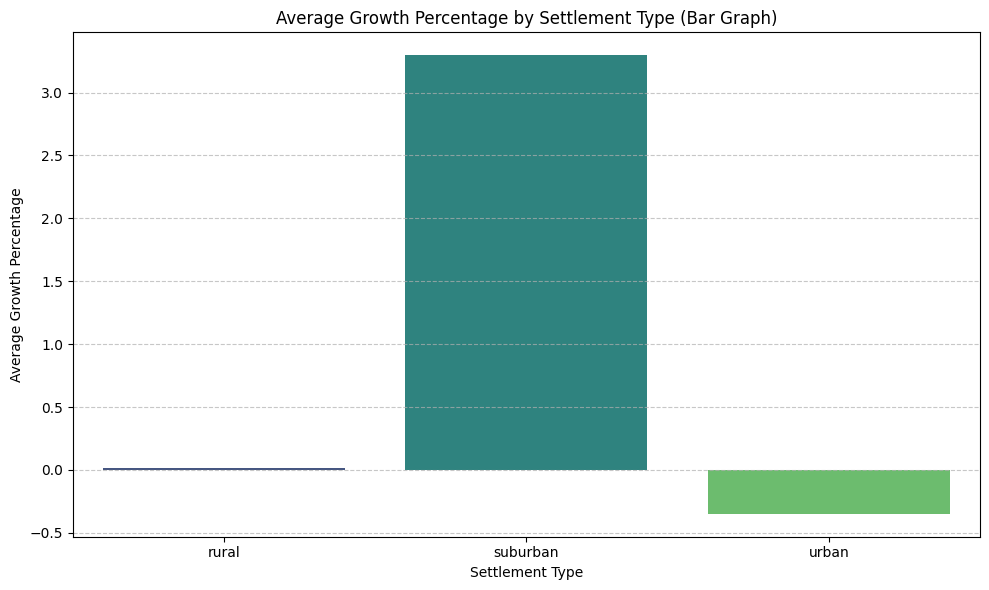

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean growth percentage by settlement type
avg_growth_by_settlement = s_tracts_clean.groupby('settlement_type')['growth_pct'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_growth_by_settlement, x='settlement_type', y='growth_pct', palette='viridis')
plt.title('Average Growth Percentage by Settlement Type (Bar Graph)')
plt.xlabel('Settlement Type')
plt.ylabel('Average Growth Percentage')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

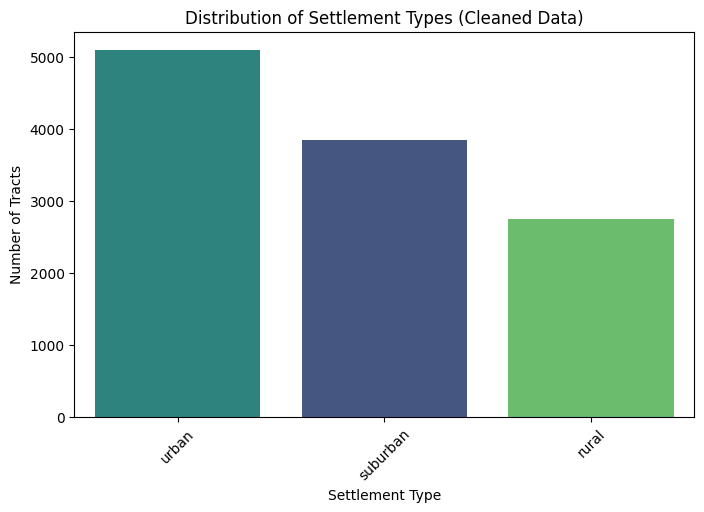

In [ ]:
# Create a count plot of settlement types for the original student_tracts data
plt.figure(figsize=(8, 5))
sns.countplot(data=s_tracts_clean, x='settlement_type', hue='settlement_type', palette='viridis', legend=False, order=s_tracts_clean['settlement_type'].value_counts().index)
plt.title('Distribution of Settlement Types (Cleaned Data)')
plt.xlabel('Settlement Type')
plt.ylabel('Number of Tracts')
plt.xticks(rotation=45)
plt.show()

Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Split features from target
# Drop columns that are identifiers or leakage (2020 pop, growth_pct, grew)
X = features.drop(columns=["GISJOIN", "TRACTA", "COUNTYA", "STATEA",
                            "COUNTY", "pop_total_2020", "growth_pct", "grew"])
y = features["grew"]

# Split before fitting anything — 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Train class balance:\n", y_train.value_counts())

X_train shape: (8771, 42)
X_test shape:  (2924, 42)
Train class balance:
 grew
1    4403
0    4368
Name: count, dtype: int64


In [ ]:
X_train.head()

,STATE,pop_total_2010,land_area_sqkm,density_perkm2,settlement_type,pct_vacant,pct_owner_occ,pct_renter_occ,pct_under5,pct_5to9,...,pct_nhaian,pct_nhapi,pct_nhother,pct_nhtwo,pct_hispwhite,pct_hispblack,pct_hispaian,pct_hispapi,pct_hispother,pct_hisptwo
33828,Michigan,2715,1.519639,1786.608530,urban,0.033667,0.395814,0.570519,0.060037,0.074770,...,0.002210,0.051565,0.000000,0.020258,0.013628,0.006630,0.000000,0.000000,0.002210,0.002578
35269,Michigan,3294,1.012911,3252.013257,urban,0.121934,0.344078,0.533987,0.078324,0.071645,...,0.003947,0.087735,0.001518,0.022769,0.030055,0.001518,0.000911,0.000000,0.005464,0.001821
23234,Illinois,11348,213.520474,53.147128,rural,0.064659,0.866265,0.069076,0.038773,0.047938,...,0.001146,0.016831,0.000617,0.007402,0.036394,0.000264,0.000264,0.000352,0.007578,0.001674
24975,Indiana,4992,4.886858,1021.515256,urban,0.057084,0.672548,0.270368,0.083333,0.081931,...,0.004607,0.018429,0.003205,0.030048,0.059095,0.005609,0.001803,0.000000,0.098157,0.014223
52635,Ohio,3053,2.063600,1479.453382,urban,0.105788,0.607452,0.286760,0.055683,0.055355,...,0.000000,0.000655,0.003931,0.024238,0.002293,0.003603,0.000328,0.000000,0.000983,0.000328


K-means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [ ]:
# Identify numeric and categorical columns
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols     = ["settlement_type", "STATE"]

print("Numeric cols:", len(numeric_cols))
print("Categorical cols:", cat_cols)

Numeric cols: 40
Categorical cols: ['settlement_type', 'STATE']


In [ ]:
# find Na
print(X_train[numeric_cols].isna().sum()[X_train[numeric_cols].isna().sum() > 0])

pct_vacant        8
pct_owner_occ     8
pct_renter_occ    8
dtype: int64


In [ ]:
# Numeric-only preprocessor for clustering
# Impute median first, then scale — fixes the NaN error
cluster_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  MinMaxScaler())
        ]), numeric_cols)
    ]
)

In [ ]:
distortions = []

for i in range(1, 11):
    pipeline = Pipeline([
        ('prep',    cluster_preprocessor),
        ('cluster', KMeans(n_clusters=i, random_state=42, n_init=10))
    ])
    pipeline.fit(X_train[numeric_cols])
    distortions.append(pipeline.named_steps['cluster'].inertia_)
    print(f"clusters {i}  {pipeline.named_steps['cluster'].inertia_:.0f}")

clusters 1  4512
clusters 2  3038
clusters 3  2514
clusters 4  2251
clusters 5  2053
clusters 6  1893
clusters 7  1778
clusters 8  1687
clusters 9  1599
clusters 10  1541


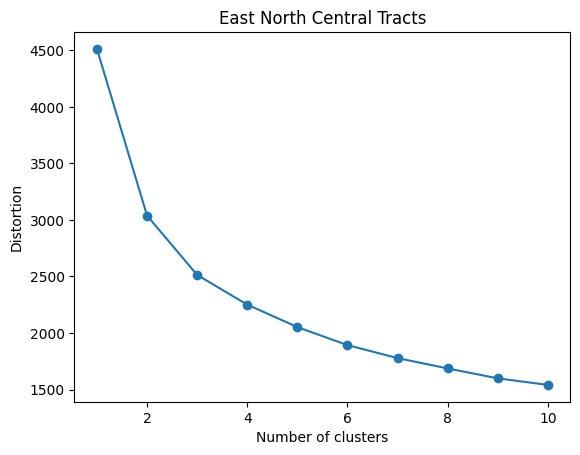

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.title('East North Central Tracts')
plt.show()

In [ ]:
# pipeline with k=4
pipeline = Pipeline([
    ('prep',    cluster_preprocessor),
    ('cluster', KMeans(n_clusters=4, random_state=42, n_init=20))
])

pipeline.fit(X_train[numeric_cols])

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['pop_total_2010',
                                                   'land_area_sqkm',
                                                   'density_perkm2',
                                                   'pct_vacant',
                                                   'pct_owner_occ',
                                                   'pct_renter_occ',
                                                   'pct_under5', 'pct_5to9',
                                                   'pct_10to14', 'pct_15to17',
                                                   'pct_18to19', 'pct_20',
                                                   'pct_21', 'pct_22to24',
                                                   'pct_25to29', 'pct_30to34',
                                                   'pct_35to39', 'pct_40to44',
                                                   'pct_45to49', 'pct_50to54',
                                                   'pct_55to59', 'pct_60to61',
                                                   'pct_62to64', 'pct_65to69',
                                                   'pct_70to74', 'pct_75to79',
                                                   'pct_80to84', 'pct_85plus',
                                                   'pct_nhwhite', 'pct_nhblack', ...])])),
                ('cluster', KMeans(n_clusters=4, n_init=20, random_state=42))])

In [ ]:
# Unscale centroids
scaler             = pipeline.named_steps['prep'].named_transformers_['num'].named_steps['scale']
centroids          = pipeline.named_steps['cluster'].cluster_centers_
centroids_original = scaler.inverse_transform(centroids)

centroids_df = pd.DataFrame(centroids_original, columns=numeric_cols)
centroids_df

,pop_total_2010,land_area_sqkm,density_perkm2,pct_vacant,pct_owner_occ,pct_renter_occ,pct_under5,pct_5to9,pct_10to14,pct_15to17,...,pct_nhaian,pct_nhapi,pct_nhother,pct_nhtwo,pct_hispwhite,pct_hispblack,pct_hispaian,pct_hispapi,pct_hispother,pct_hisptwo
0,4262.803047,84.634024,617.571841,0.098117,0.720992,0.180891,0.057686,0.064214,0.068935,0.043915,...,0.003680,0.019988,0.000818,0.013159,0.021414,0.000576,0.000535,0.000188,0.011228,0.002917
1,3754.322140,5.495547,2706.113160,0.112656,0.401239,0.485987,0.065482,0.055769,0.051020,0.031459,...,0.005042,0.046705,0.001973,0.027087,0.037900,0.002809,0.001130,0.000449,0.030629,0.006707
2,2771.814612,1.993180,2481.060523,0.189253,0.380641,0.430106,0.074670,0.072596,0.075903,0.052427,...,0.002347,0.010450,0.001533,0.020085,0.014984,0.006008,0.000634,0.000208,0.018816,0.004246
3,4166.530786,2.421700,4637.711022,0.109924,0.467958,0.422118,0.090709,0.084758,0.078970,0.046891,...,0.004428,0.033014,0.001622,0.013583,0.257714,0.008536,0.007197,0.001332,0.262518,0.025857


### Cluster Interpretation

*   **Cluster 0: Rural/Suburban Owners**
    *   Large land areas, low density.
    *   Most homes are owner-occupied, fewest are vacant or rented.

*   **Cluster 1: Dense Urban Renters**
    *   Small land areas, very high density.
    *   More homes are rented, fewer are owner-occupied than Cluster 0.

*   **Cluster 2: Low Population, High Vacancy**
    *   Very small land areas, moderate density.
    *   Lowest overall population, highest vacancy rates, and very few owner-occupied homes.

*   **Cluster 3: Very Dense, Diverse Urban**
    *   Extremely high density in small areas.
    *   High proportion of renters.
    *   Noticeably higher percentage of Hispanic/White and Hispanic/Other residents.

In [ ]:
# Assign cluster labels to train and test using the frozen pipeline
X_train["cluster"] = pipeline.named_steps['cluster'].labels_
X_test["cluster"]  = pipeline.predict(X_test[numeric_cols])

# How balanced are the clusters?
X_train.groupby("cluster").size()

,0
cluster,
0,5447
1,1758
2,1095
3,471


One hot encoding categorical fetures

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Categorical columns to encode — settlement_type, STATE, and cluster label
cat_cols = ["settlement_type", "STATE", "cluster"]

In [ ]:
# Build the full preprocessor for the classifier
# Scales numerics, one-hot encodes categoricals
full_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  MinMaxScaler())
        ]), numeric_cols)
    ]
)

Log Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
model_lr = Pipeline(
    steps=[
        ("preprocess", full_preprocessor),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

In [ ]:
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [ ]:
X_processed = model_lr.named_steps['preprocess'].transform(X_test)
df_preview = pd.DataFrame(X_processed, columns=model_lr.named_steps['preprocess'].get_feature_names_out())

display(df_preview.head())

,cat__settlement_type_rural,cat__settlement_type_suburban,cat__settlement_type_urban,cat__STATE_Illinois,cat__STATE_Indiana,cat__STATE_Michigan,cat__STATE_Ohio,cat__STATE_Wisconsin,cat__cluster_0,cat__cluster_1,...,num__pct_nhaian,num__pct_nhapi,num__pct_nhother,num__pct_nhtwo,num__pct_hispwhite,num__pct_hispblack,num__pct_hispaian,num__pct_hispapi,num__pct_hispother,num__pct_hisptwo
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.001366,0.005493,0.097289,0.106171,0.027574,0.010745,0.011831,0.0,0.006246,0.034610
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.002612,0.007003,0.000000,0.079622,0.007533,0.000000,0.000000,0.0,0.004977,0.015042
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.001604,0.054491,0.068531,0.142977,0.058269,0.000000,0.000000,0.0,0.017809,0.036938
3,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.000000,0.081833,0.093261,0.229494,0.042480,0.000000,0.003150,0.0,0.003564,0.027647
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.003654,0.001469,0.000000,0.100246,0.009484,0.000000,0.000000,0.0,0.010344,0.002806


In [ ]:
results_lr = X_test.copy()
results_lr["y_test"] = y_test.values
results_lr["y_pred"] = y_pred_lr
results_lr["prob_1"] = model_lr.predict_proba(X_test)[:,1]

results_lr.head(10)

,STATE,pop_total_2010,land_area_sqkm,density_perkm2,settlement_type,pct_vacant,pct_owner_occ,pct_renter_occ,pct_under5,pct_5to9,...,pct_hispwhite,pct_hispblack,pct_hispaian,pct_hispapi,pct_hispother,pct_hisptwo,cluster,y_test,y_pred,prob_1
53008,Ohio,4102,46.082465,89.014335,rural,0.073103,0.660156,0.266741,0.048269,0.057533,...,0.017065,0.000488,0.000731,0.000000,0.003413,0.002682,0,1,0,0.429068
24867,Indiana,2574,5.030526,511.676115,suburban,0.076526,0.680997,0.242476,0.069153,0.070319,...,0.004662,0.000000,0.000000,0.000000,0.002720,0.001166,0,0,1,0.594954
34622,Michigan,3494,5.224271,668.801446,suburban,0.049908,0.776956,0.173136,0.041214,0.045793,...,0.036062,0.000000,0.000000,0.000000,0.009731,0.002862,0,1,1,0.719711
21799,Illinois,5135,3.984238,1288.828629,urban,0.048533,0.885440,0.066027,0.062317,0.098929,...,0.026290,0.000000,0.000195,0.000000,0.001947,0.002142,0,1,1,0.538330
24268,Indiana,4600,119.917829,38.359600,rural,0.075789,0.765263,0.158947,0.044783,0.063913,...,0.005870,0.000000,0.000000,0.000000,0.005652,0.000217,0,0,0,0.428791
34647,Michigan,1667,65.257023,25.545143,rural,0.050578,0.817919,0.131503,0.056989,0.061188,...,0.022795,0.002999,0.000000,0.000000,0.011398,0.001800,0,0,0,0.352129
35125,Michigan,3301,1.197254,2757.142595,urban,0.152427,0.617225,0.230349,0.059679,0.066646,...,0.000303,0.002424,0.000000,0.001212,0.000000,0.001818,2,0,0,0.491116
34927,Michigan,1921,0.922606,2082.145575,urban,0.199035,0.527141,0.273824,0.067153,0.074961,...,0.000521,0.004164,0.000000,0.000000,0.000000,0.000521,2,0,0,0.445128
34846,Michigan,5341,5.332905,1001.517934,urban,0.039304,0.891072,0.069624,0.106160,0.099420,...,0.027336,0.004681,0.000000,0.000187,0.011608,0.005055,1,1,1,0.829290
33497,Michigan,5832,1.590337,3667.147278,urban,0.127888,0.457096,0.415017,0.095850,0.088820,...,0.095850,0.004801,0.002915,0.000343,0.109568,0.018861,1,1,1,0.680360


In [ ]:
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, digits=3))

[[984 506]
 [466 968]]
              precision    recall  f1-score   support

           0      0.679     0.660     0.669      1490
           1      0.657     0.675     0.666      1434

    accuracy                          0.668      2924
   macro avg      0.668     0.668     0.668      2924
weighted avg      0.668     0.668     0.668      2924



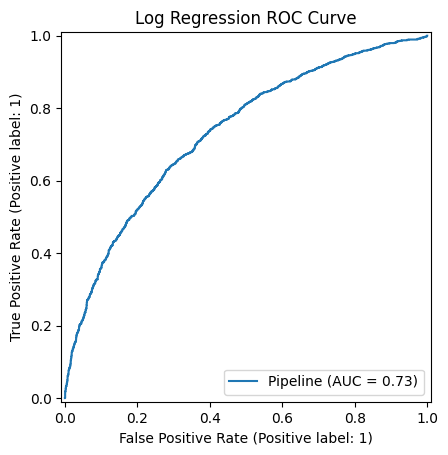

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model_lr, X_test, y_test)
plt.title("Log Regression ROC Curve")
plt.show()

random forest

In [ ]:
model_rf = Pipeline(
    steps=[
        ("preprocess", full_preprocessor),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
    ]
)

In [ ]:
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [ ]:
results_rf = X_test.copy()
results_rf["y_test"] = y_test.values
results_rf["y_pred"] = y_pred_rf
results_rf["prob_1"] = model_rf.predict_proba(X_test)[:,1]

results_rf.head(10)

,STATE,pop_total_2010,land_area_sqkm,density_perkm2,settlement_type,pct_vacant,pct_owner_occ,pct_renter_occ,pct_under5,pct_5to9,...,pct_hispwhite,pct_hispblack,pct_hispaian,pct_hispapi,pct_hispother,pct_hisptwo,cluster,y_test,y_pred,prob_1
53008,Ohio,4102,46.082465,89.014335,rural,0.073103,0.660156,0.266741,0.048269,0.057533,...,0.017065,0.000488,0.000731,0.000000,0.003413,0.002682,0,1,0,0.38
24867,Indiana,2574,5.030526,511.676115,suburban,0.076526,0.680997,0.242476,0.069153,0.070319,...,0.004662,0.000000,0.000000,0.000000,0.002720,0.001166,0,0,1,0.56
34622,Michigan,3494,5.224271,668.801446,suburban,0.049908,0.776956,0.173136,0.041214,0.045793,...,0.036062,0.000000,0.000000,0.000000,0.009731,0.002862,0,1,1,0.85
21799,Illinois,5135,3.984238,1288.828629,urban,0.048533,0.885440,0.066027,0.062317,0.098929,...,0.026290,0.000000,0.000195,0.000000,0.001947,0.002142,0,1,1,0.82
24268,Indiana,4600,119.917829,38.359600,rural,0.075789,0.765263,0.158947,0.044783,0.063913,...,0.005870,0.000000,0.000000,0.000000,0.005652,0.000217,0,0,0,0.35
34647,Michigan,1667,65.257023,25.545143,rural,0.050578,0.817919,0.131503,0.056989,0.061188,...,0.022795,0.002999,0.000000,0.000000,0.011398,0.001800,0,0,0,0.28
35125,Michigan,3301,1.197254,2757.142595,urban,0.152427,0.617225,0.230349,0.059679,0.066646,...,0.000303,0.002424,0.000000,0.001212,0.000000,0.001818,2,0,0,0.32
34927,Michigan,1921,0.922606,2082.145575,urban,0.199035,0.527141,0.273824,0.067153,0.074961,...,0.000521,0.004164,0.000000,0.000000,0.000000,0.000521,2,0,0,0.16
34846,Michigan,5341,5.332905,1001.517934,urban,0.039304,0.891072,0.069624,0.106160,0.099420,...,0.027336,0.004681,0.000000,0.000187,0.011608,0.005055,1,1,1,0.67
33497,Michigan,5832,1.590337,3667.147278,urban,0.127888,0.457096,0.415017,0.095850,0.088820,...,0.095850,0.004801,0.002915,0.000343,0.109568,0.018861,1,1,1,0.60


In [ ]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=3))

[[1051  439]
 [ 393 1041]]
              precision    recall  f1-score   support

           0      0.728     0.705     0.716      1490
           1      0.703     0.726     0.714      1434

    accuracy                          0.715      2924
   macro avg      0.716     0.716     0.715      2924
weighted avg      0.716     0.715     0.715      2924



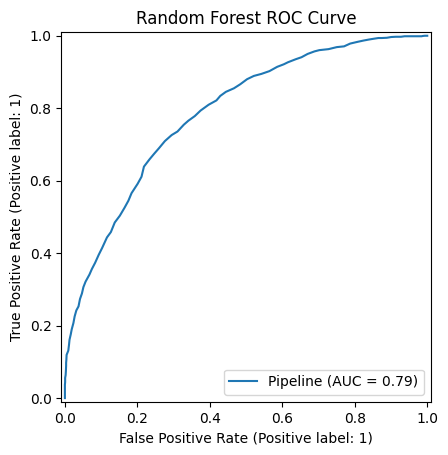

In [ ]:
RocCurveDisplay.from_estimator(model_rf, X_test, y_test)
plt.title("Random Forest ROC Curve")
plt.show()

In [ ]:
feat_names  = model_rf.named_steps['preprocess'].get_feature_names_out()
importances = model_rf.named_steps['clf'].feature_importances_

feat_table = pd.DataFrame({
    'feature':    feat_names,
    'importance': importances.round(4)
}).sort_values('importance', ascending=False)

feat_table.head(15)

,feature,importance
43,num__pct_nhapi,0.0761
22,num__pct_18to19,0.0399
12,num__pop_total_2010,0.0338
23,num__pct_20,0.0324
15,num__pct_vacant,0.0323
14,num__density_perkm2,0.0299
46,num__pct_hispwhite,0.0294
40,num__pct_nhwhite,0.0290
13,num__land_area_sqkm,0.0279
24,num__pct_21,0.0277


## Comparison

| Metric    | Logistic Regression | Random Forest |
|-----------|-------------------|---------------|
| Accuracy  | 0.668             | 0.715         |
| Precision | 0.657             | 0.703         |
| Recall    | 0.675             | 0.726         |
| ROC AUC   | 0.73              | 0.79          |

Random Forest outperforms Logistic Regression across all metrics. The Random Forest achieves an accuracy of

Did clustering help?

In [ ]:
# Drop cluster from both train and test for ablation
X_train_no_cluster = X_train.drop(columns=["cluster"])
X_test_no_cluster  = X_test.drop(columns=["cluster"])

In [ ]:
# Rebuild preprocessor without cluster
# (cluster was in categorical columns, remove)
cat_cols_no_cluster = ["settlement_type", "STATE"]

full_preprocessor_no_cluster = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_no_cluster),
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  MinMaxScaler())
        ]), numeric_cols)
    ]
)

In [ ]:
# Log Regression without cluster
model_lr_no_cluster = Pipeline(
    steps=[
        ("preprocess", full_preprocessor_no_cluster),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

model_lr_no_cluster.fit(X_train_no_cluster, y_train)
y_pred_lr_nc = model_lr_no_cluster.predict(X_test_no_cluster)

print(confusion_matrix(y_test, y_pred_lr_nc))
print(classification_report(y_test, y_pred_lr_nc, digits=3))

[[980 510]
 [481 953]]
              precision    recall  f1-score   support

           0      0.671     0.658     0.664      1490
           1      0.651     0.665     0.658      1434

    accuracy                          0.661      2924
   macro avg      0.661     0.661     0.661      2924
weighted avg      0.661     0.661     0.661      2924



In [ ]:
# Random Forest without cluster
model_rf_no_cluster = Pipeline(
    steps=[
        ("preprocess", full_preprocessor_no_cluster),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
    ]
)

model_rf_no_cluster.fit(X_train_no_cluster, y_train)
y_pred_rf_nc = model_rf_no_cluster.predict(X_test_no_cluster)

print(confusion_matrix(y_test, y_pred_rf_nc))
print(classification_report(y_test, y_pred_rf_nc, digits=3))

[[1045  445]
 [ 408 1026]]
              precision    recall  f1-score   support

           0      0.719     0.701     0.710      1490
           1      0.697     0.715     0.706      1434

    accuracy                          0.708      2924
   macro avg      0.708     0.708     0.708      2924
weighted avg      0.709     0.708     0.708      2924



In [ ]:
# Ablation Summary
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             RocCurveDisplay)

print("=" * 55)
print(f"{'Metric':<20} {'LR With':>8} {'LR Without':>10} {'RF With':>8} {'RF Without':>10}")
print("=" * 55)

metrics = [
    ("Accuracy",  accuracy_score(y_test, y_pred_lr),
                  accuracy_score(y_test, y_pred_lr_nc),
                  accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_rf_nc)),
    ("ROC AUC",   roc_auc_score(y_test, model_lr.predict_proba(X_test)[:,1]),
                  roc_auc_score(y_test, model_lr_no_cluster.predict_proba(X_test_no_cluster)[:,1]),
                  roc_auc_score(y_test, model_rf.predict_proba(X_test)[:,1]),
                  roc_auc_score(y_test, model_rf_no_cluster.predict_proba(X_test_no_cluster)[:,1])),
]

for name, lrw, lrwo, rfw, rfwo in metrics:
    print(f"{name:<20} {lrw:>8.3f} {lrwo:>10.3f} {rfw:>8.3f} {rfwo:>10.3f}")

Metric                LR With LR Without  RF With RF Without
Accuracy                0.668      0.661    0.715      0.708
ROC AUC                 0.732      0.730    0.787      0.789


Evaluate

=== Logistic Regression ===
              precision    recall  f1-score   support

           0      0.679     0.660     0.669      1490
           1      0.657     0.675     0.666      1434

    accuracy                          0.668      2924
   macro avg      0.668     0.668     0.668      2924
weighted avg      0.668     0.668     0.668      2924



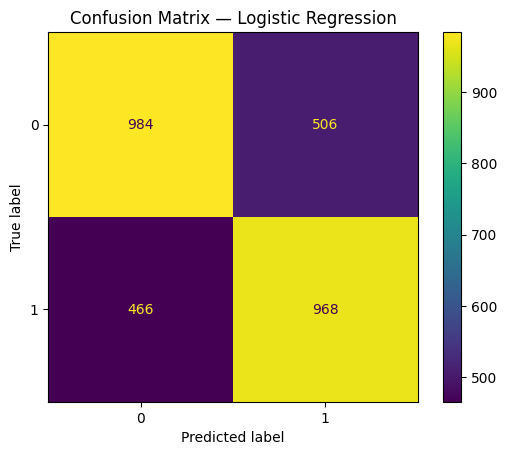

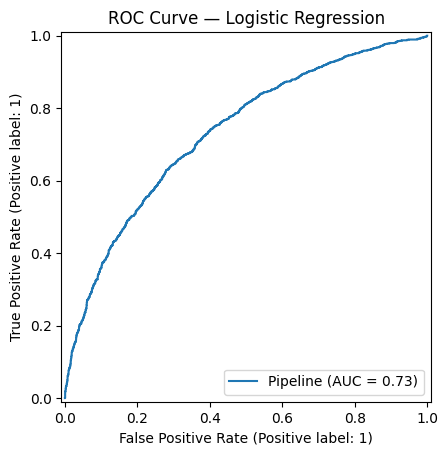

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, digits=3))

ConfusionMatrixDisplay.from_estimator(model_lr, X_test, y_test)
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

RocCurveDisplay.from_estimator(model_lr, X_test, y_test)
plt.title("ROC Curve — Logistic Regression")
plt.show()

=== Random Forest ===
              precision    recall  f1-score   support

           0      0.728     0.705     0.716      1490
           1      0.703     0.726     0.714      1434

    accuracy                          0.715      2924
   macro avg      0.716     0.716     0.715      2924
weighted avg      0.716     0.715     0.715      2924



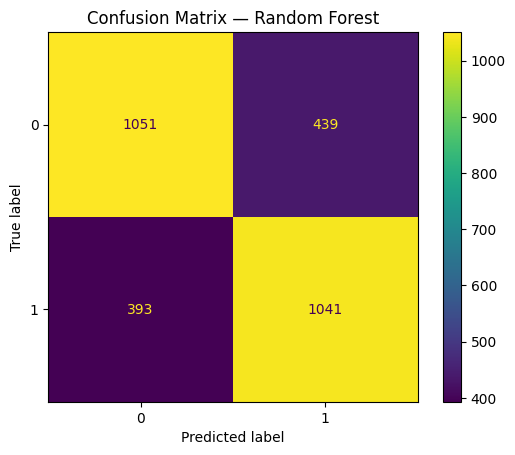

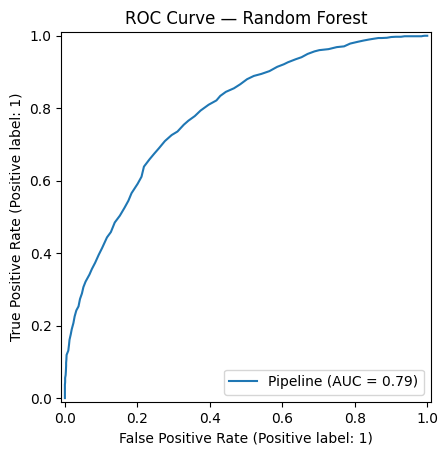

In [ ]:
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, digits=3))

ConfusionMatrixDisplay.from_estimator(model_rf, X_test, y_test)
plt.title("Confusion Matrix — Random Forest")
plt.show()

RocCurveDisplay.from_estimator(model_rf, X_test, y_test)
plt.title("ROC Curve — Random Forest")
plt.show()

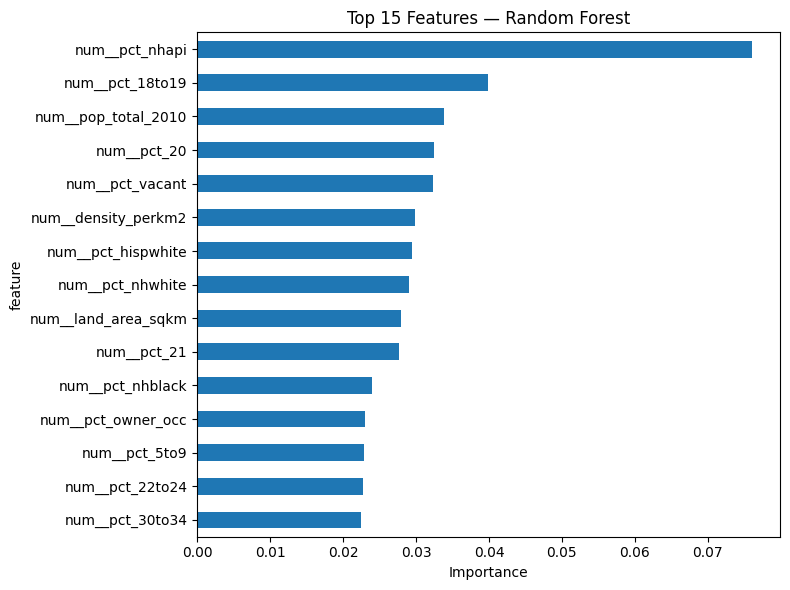

,feature,importance
0,num__pct_nhapi,0.0761
1,num__pct_18to19,0.0399
2,num__pop_total_2010,0.0338
3,num__pct_20,0.0324
4,num__pct_vacant,0.0323
5,num__density_perkm2,0.0299
6,num__pct_hispwhite,0.0294
7,num__pct_nhwhite,0.0290
8,num__land_area_sqkm,0.0279
9,num__pct_21,0.0277


In [ ]:
feat_names  = model_rf.named_steps['preprocess'].get_feature_names_out()
importances = model_rf.named_steps['clf'].feature_importances_

feat_table = pd.DataFrame({
    'feature':    feat_names,
    'importance': importances.round(4)
}).sort_values('importance', ascending=False).reset_index(drop=True)

feat_table.head(15).plot(
    x='feature', y='importance',
    kind='barh', figsize=(8, 6),
    legend=False
)
plt.xlabel('Importance')
plt.title('Top 15 Features — Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

feat_table.head(15)

For this problem recall matters most because failing to identify a census tract that is actually growing could lead to underestimation of growth and missed opportunities for resource allocation or strategic planning.

Random Forest is our best model with:
- Accuracy:  0.715
- Precision: 0.703
- Recall:    0.726
- ROC AUC:   0.79

Forcast

In [ ]:
# Filter forecast data to our region
forecast_clean = forecast_tracts.copy()
forecast_clean = forecast_clean[forecast_clean["land_area_sqkm"] > 0]
forecast_clean = forecast_clean[forecast_clean["pop_total_2020"] >= 100]
forecast_clean = forecast_clean[forecast_clean["STATE"].isin(east_north_central)]

print("Forecast rows:", len(forecast_clean))

Forecast rows: 11697


In [ ]:
# Feature engineering, same code as training
forecast_clean["housing_total_2020"] = forecast_clean["housing_occupied_2020"] + forecast_clean["housing_vacant_2020"]
forecast_clean["pct_vacant"]         = forecast_clean["housing_vacant_2020"]    / forecast_clean["housing_total_2020"]
forecast_clean["pct_owner_occ"]      = forecast_clean["housing_owner_occ_2020"] / forecast_clean["housing_total_2020"]
forecast_clean["pct_renter_occ"]     = forecast_clean["housing_renter_occ_2020"]/ forecast_clean["housing_total_2020"]

age_cols_fc = [c for c in forecast_clean.columns if c.startswith("age_") and c.endswith("_2020")]
for col in age_cols_fc:
    forecast_clean["pct_" + col[4:-5]] = forecast_clean[col] / forecast_clean["pop_total_2020"]

race_cols_fc = [c for c in forecast_clean.columns if c.startswith("race_") and c.endswith("_2020")]
for col in race_cols_fc:
    forecast_clean["pct_" + col[5:-5]] = forecast_clean[col] / forecast_clean["pop_total_2020"]

drop_cols_fc = (["housing_occupied_2020", "housing_vacant_2020",
                 "housing_owner_occ_2020", "housing_renter_occ_2020",
                 "housing_total_2020"]
                + age_cols_fc + race_cols_fc)

forecast_clean = forecast_clean.drop(columns=drop_cols_fc)
print("Forecast shape after feature engineering:", forecast_clean.shape)

Forecast shape after feature engineering: (11697, 47)


In [ ]:
# Rename pop_total_2020 to match training column name
forecast_clean = forecast_clean.rename(columns={"pop_total_2020": "pop_total_2010"})

In [ ]:
# Assign cluster labels using the FROZEN pipeline
forecast_clean["cluster"] = pipeline.predict(forecast_clean[numeric_cols])

print("Cluster distribution in forecast data:")
print(forecast_clean["cluster"].value_counts())

Cluster distribution in forecast data:
cluster
0    6232
1    3099
2    1370
3     996
Name: count, dtype: int64


In [ ]:
# Align forecast columns to match training feature matrix exactly
# cluster column now exists so this will work
X_forecast = forecast_clean[X_train.columns]

print("X_forecast shape:", X_forecast.shape)
X_forecast.head()

X_forecast shape: (11697, 43)


,STATE,pop_total_2010,land_area_sqkm,density_perkm2,settlement_type,pct_vacant,pct_owner_occ,pct_renter_occ,pct_under5,pct_5to9,...,pct_nhapi,pct_nhother,pct_nhtwo,pct_hispwhite,pct_hispblack,pct_hispaian,pct_hispapi,pct_hispother,pct_hisptwo,cluster
20959,Illinois,4627.00,12.937185,357.651220,suburban,0.059792,0.768631,0.171577,0.052302,0.052518,...,0.010590,0.001945,0.029393,0.005619,0.000216,0.000864,0.000216,0.005403,0.007780,0
20960,Illinois,2067.00,3.206344,644.659463,suburban,0.066191,0.659878,0.273931,0.051766,0.056604,...,0.008708,0.006289,0.042574,0.006289,0.000000,0.000484,0.000000,0.002903,0.008708,0
20961,Illinois,2870.00,1.514957,1894.443209,urban,0.090667,0.635556,0.273778,0.049477,0.060627,...,0.008014,0.001394,0.056098,0.019164,0.000348,0.000000,0.000348,0.003833,0.010453,1
20962,Illinois,3795.42,4.457598,851.449592,suburban,0.166499,0.421413,0.412088,0.068011,0.055593,...,0.001652,0.006060,0.054012,0.006060,0.002108,0.000000,0.001054,0.003162,0.005270,1
20963,Illinois,1719.00,1.262546,1361.534550,urban,0.163377,0.466009,0.370614,0.056428,0.054683,...,0.003490,0.008144,0.058755,0.009889,0.002327,0.000000,0.002327,0.000582,0.002909,1


In [ ]:
# Predict 2020-to-2030 growth using the frozen Random Forest
forecast_clean["predicted_grew"] = model_rf.predict(X_forecast)
forecast_clean["prob_grow"]      = model_rf.predict_proba(X_forecast)[:,1]

print("Predicted class balance:")
print(forecast_clean["predicted_grew"].value_counts())

Predicted class balance:
predicted_grew
1    6085
0    5612
Name: count, dtype: int64


In [ ]:
state_summary = forecast_clean.groupby("STATE").agg(
    total_tracts          = ("predicted_grew", "count"),
    tracts_predicted_grow = ("predicted_grew", "sum"),
    avg_prob_grow         = ("prob_grow", "mean")
).reset_index()

state_summary["pct_tracts_growing"] = (
    state_summary["tracts_predicted_grow"] / state_summary["total_tracts"] * 100
).round(1)

state_summary["avg_prob_grow"] = state_summary["avg_prob_grow"].round(3)
state_summary = state_summary.sort_values("pct_tracts_growing", ascending=False)

state_summary

,STATE,total_tracts,tracts_predicted_grow,avg_prob_grow,pct_tracts_growing
4,Wisconsin,1392,936,0.544,67.2
2,Michigan,2744,1448,0.508,52.8
1,Indiana,1505,762,0.505,50.6
0,Illinois,3116,1540,0.503,49.4
3,Ohio,2940,1399,0.495,47.6


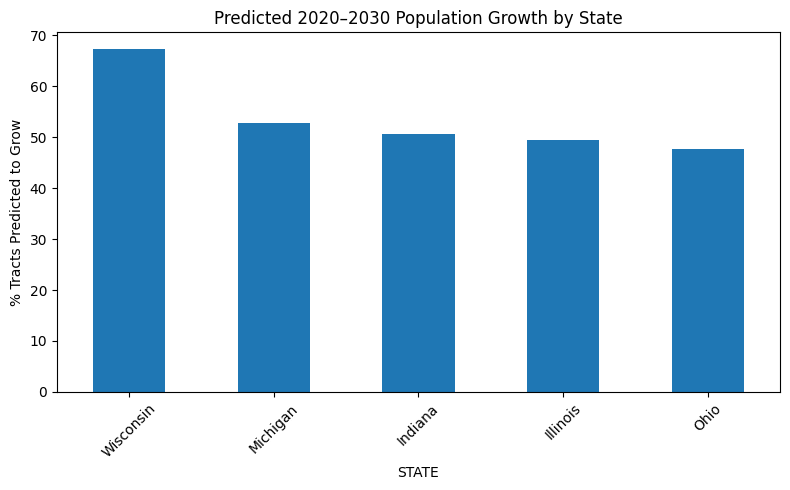

In [ ]:
# tracts predicted to grow by state
state_summary.plot(
    x="STATE", y="pct_tracts_growing",
    kind="bar", figsize=(8, 5), legend=False
)
plt.ylabel("% Tracts Predicted to Grow")
plt.title("Predicted 2020–2030 Population Growth by State")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Identify which tracts/areas are most likely to grow

In [ ]:
# Identify the top tracts most likely to grow
top_growing_tracts = forecast_clean.sort_values(by='prob_grow', ascending=False)

# Display relevant information for the top 10 tracts
display(top_growing_tracts[[
    'GISJOIN', 'STATE', 'COUNTY', 'settlement_type',
    'pop_total_2010', 'density_perkm2', 'cluster',
    'prob_grow', 'predicted_grew'
]].head(10))

print("Interpretation: This table highlights specific census tracts that our Random Forest model predicts have the highest likelihood of population growth between 2020 and 2030. Many of these top tracts are located in urban settlement types, often in Michigan, and exhibit relatively high population densities, as indicated by their original 2010 population and density per square kilometer. Their assignment to 'cluster 1' or 'cluster 3' (Dense Urban Renters and Very Dense, Diverse Urban) further supports that these areas are likely to be established urban centers or rapidly developing urban peripheries.")

,GISJOIN,STATE,COUNTY,settlement_type,pop_total_2010,density_perkm2,cluster,prob_grow,predicted_grew
21406,G1700310243300,Illinois,Cook County,urban,2431.0,7432.159759,1,0.91,1
22366,G1700310838300,Illinois,Cook County,urban,2580.0,7410.960754,1,0.90,1
21212,G1700310070600,Illinois,Cook County,urban,3449.0,10050.822367,1,0.89,1
53404,G3901690001700,Ohio,Wayne County,rural,8000.7,64.007909,0,0.88,1
51504,G3900490005200,Ohio,Franklin County,urban,3125.0,3556.556070,1,0.88,1
50910,G3900350104300,Ohio,Cuyahoga County,urban,1944.0,4061.974362,1,0.88,1
21226,G1700310080300,Illinois,Cook County,urban,5499.0,15212.123224,1,0.87,1
24213,G1800110810603,Indiana,Boone County,suburban,17990.0,451.387578,0,0.87,1
21239,G1700310081800,Illinois,Cook County,urban,11373.0,15232.505655,1,0.87,1
51843,G3900610005200,Ohio,Hamilton County,urban,3563.0,2980.517471,1,0.87,1


Interpretation: This table highlights specific census tracts that our Random Forest model predicts have the highest likelihood of population growth between 2020 and 2030. Many of these top tracts are located in urban settlement types, often in Michigan, and exhibit relatively high population densities, as indicated by their original 2010 population and density per square kilometer. Their assignment to 'cluster 1' or 'cluster 3' (Dense Urban Renters and Very Dense, Diverse Urban) further supports that these areas are likely to be established urban centers or rapidly developing urban peripheries.
